# Notebook 02 — Exploratory Data Analysis (EDA)
### NER System | Sports & Political News

Deep analysis of the cleaned dataset to understand entity patterns.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import re, os, warnings
warnings.filterwarnings('ignore')
print('Libraries loaded OK')

Libraries loaded OK


## Step 1 — Load Cleaned Data

In [2]:
df = pd.read_csv('../data/cleaned_data.csv')
print(f'Rows: {len(df)}')
print(f'Columns: {list(df.columns)}')
df.head(5)

Rows: 1737
Columns: ['article_id', 'domain', 'sentence', 'person_entities', 'location_entities', 'has_person', 'has_location', 'has_entity', 'word_count']


,article_id,domain,sentence,person_entities,location_entities,has_person,has_location,has_entity,word_count
0,1,Sports,Max Verstappen has threatened to quit Formula ...,Max Verstappen,NONE,True,False,True,26
1,1,Sports,Governing body the FIA said two weeks ago that...,NONE,NONE,False,False,False,33
2,1,Sports,But opposition has emerged in subsequent talks...,NONE,NONE,False,False,False,30
3,1,Sports,"""If it stays like this, it's going to be a lon...",Verstappen,NONE,True,False,True,20
4,1,Sports,"""It's just mentally not doable for me to stay ...",NONE,NONE,False,False,False,11


## Step 2 — Dataset Overview

In [3]:
print('=== DATASET OVERVIEW ===')
print(f'Total sentences  : {len(df)}')
print(f'Total articles   : {df["article_id"].nunique()}')
print(f'Domains          : {df["domain"].unique()}')

print('\n=== PER DOMAIN ===')
for d in df['domain'].unique():
    sub = df[df['domain']==d]
    print(f'{d}: {len(sub)} sentences | {sub["article_id"].nunique()} articles')

print('\n=== ENTITY STATS ===')
print(f'Has PERSON   : {df["has_person"].sum()} ({df["has_person"].mean()*100:.1f}%)')
print(f'Has LOCATION : {df["has_location"].sum()} ({df["has_location"].mean()*100:.1f}%)')
print(f'Has ENTITY   : {df["has_entity"].sum()} ({df["has_entity"].mean()*100:.1f}%)')
print(f'No Entity    : {(~df["has_entity"]).sum()} ({(~df["has_entity"]).mean()*100:.1f}%)')

=== DATASET OVERVIEW ===
Total sentences  : 1737
Total articles   : 51
Domains          : <ArrowStringArray>
['Sports', 'Politics']
Length: 2, dtype: str

=== PER DOMAIN ===
Sports: 1231 sentences | 51 articles
Politics: 506 sentences | 50 articles

=== ENTITY STATS ===
Has PERSON   : 614 (35.3%)
Has LOCATION : 504 (29.0%)
Has ENTITY   : 879 (50.6%)
No Entity    : 858 (49.4%)


## Step 3 — Entity Distribution Per Domain

In [4]:
domain_stats = df.groupby('domain')[['has_person','has_location','has_entity']].sum().reset_index()
domain_stats.columns = ['Domain','PERSON','LOCATION','Any Entity']
print(domain_stats)

     Domain  PERSON  LOCATION  Any Entity
0  Politics     137       159         241
1    Sports     477       345         638


## Step 4 — Most Frequent Person Entities

In [5]:
all_persons = []
for p in df[df['has_person']]['person_entities']:
    all_persons.extend([x.strip() for x in str(p).split(',') if x.strip() and x.strip()!='NONE'])

from collections import Counter
person_freq = Counter(all_persons)
top_persons = pd.DataFrame(person_freq.most_common(20), columns=['Person','Count'])
print('TOP 20 PERSON ENTITIES:')
print(top_persons.to_string(index=False))

TOP 20 PERSON ENTITIES:
   Person  Count
     Usyk     22
Verhoeven     19
  Glasner     17
    Toone     15
Andreescu     13
 Putellas     11
   Devine     10
Guardiola      9
   Neymar      9
    Allen      8
   Parish      8
 Williams      7
   Iraola      7
    Brier      7
     Nick      7
      Cox      7
     Khan      7
   Hesson      7
Korpatsch      6
  Shehbaz      6


## Step 5 — Most Frequent Location Entities

In [6]:
all_locs = []
for l in df[df['has_location']]['location_entities']:
    all_locs.extend([x.strip() for x in str(l).split(',') if x.strip() and x.strip()!='NONE'])

loc_freq = Counter(all_locs)
top_locs = pd.DataFrame(loc_freq.most_common(20), columns=['Location','Count'])
print('TOP 20 LOCATION ENTITIES:')
print(top_locs.to_string(index=False))

TOP 20 LOCATION ENTITIES:
   Location  Count
    England     54
   Pakistan     53
      India     32
 Manchester     28
    Arsenal     20
   Scotland     19
New Zealand     18
       Iran     16
     London     15
  Barcelona     14
  Newcastle     13
  Liverpool     13
  Australia     13
    Ireland     12
   Brighton     12
         US     11
      Wales     11
     Brazil     10
    Chelsea     10
      Paris      9


## Step 6 — EDA Visualizations

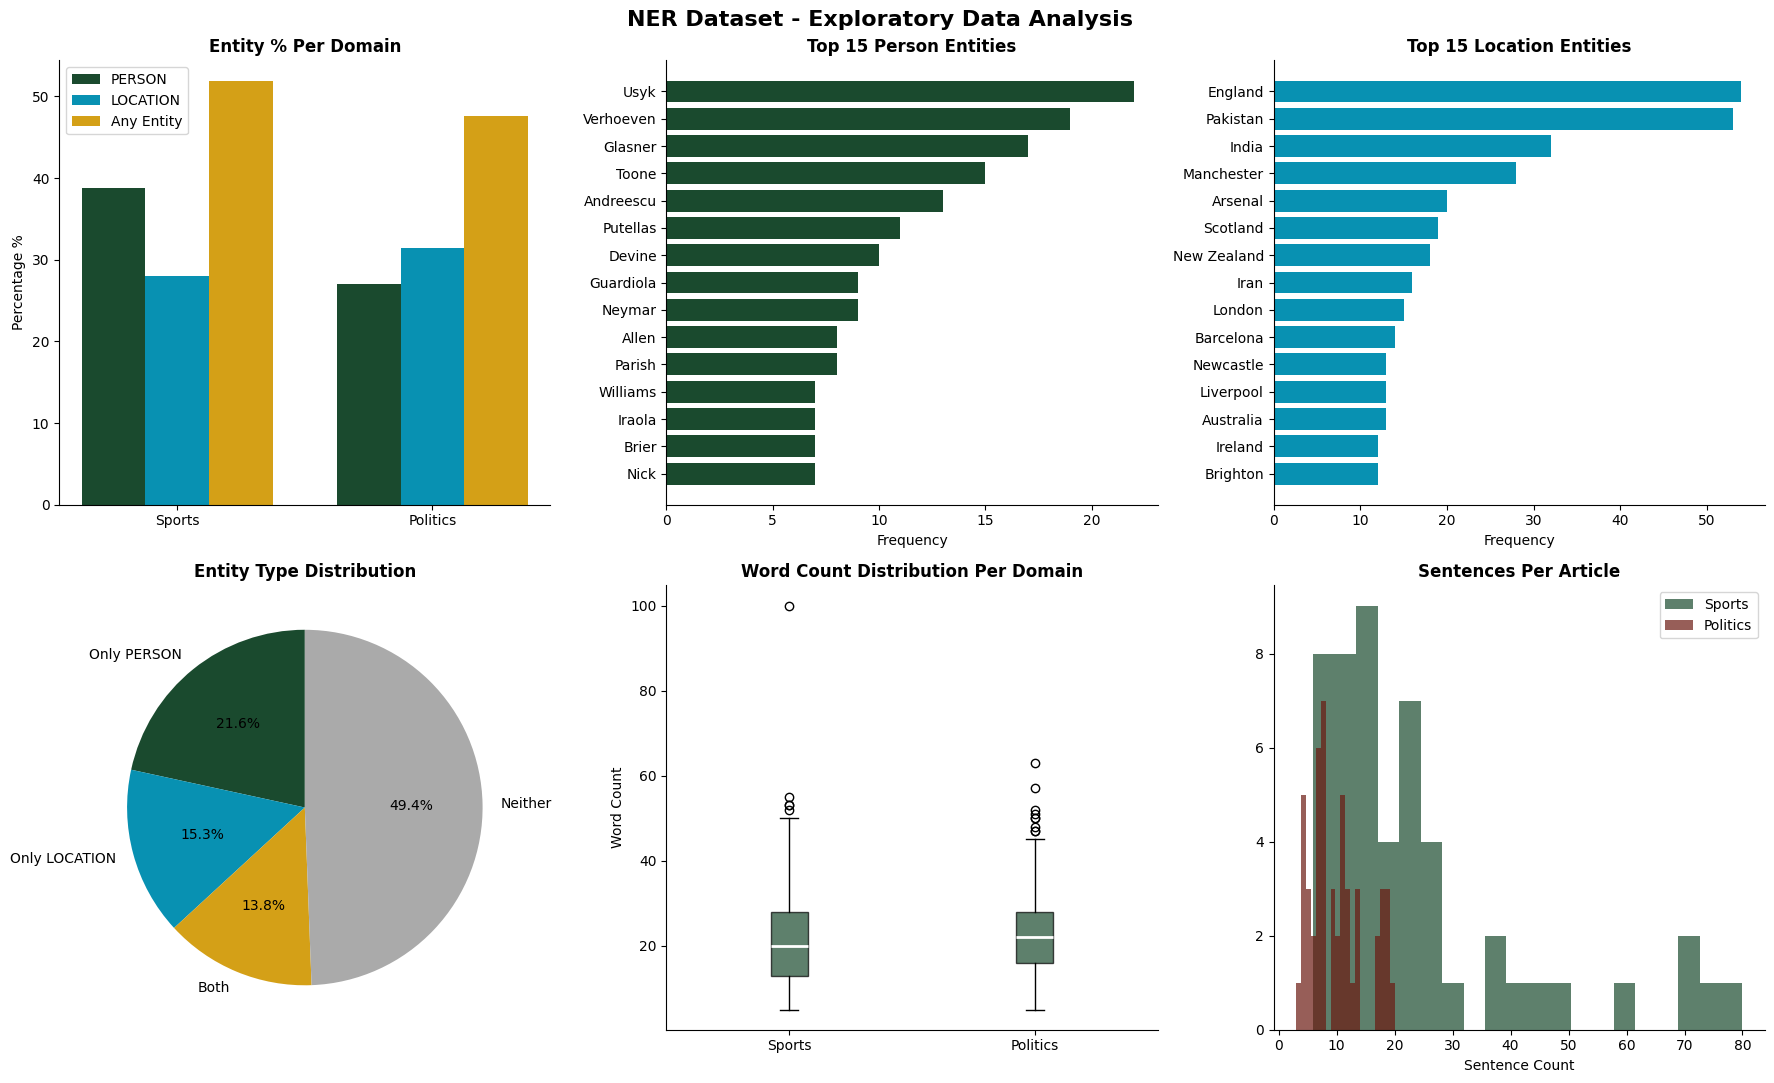

EDA charts saved


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('NER Dataset - Exploratory Data Analysis', fontsize=16, fontweight='bold')
GREEN,RED,TEAL,GOLD='#1A4A2E','#6B1A11','#0891B2','#D4A017'

# Plot 1: Entity % per domain
x=np.arange(2); w=0.25
pers_pct=[df[df['domain']==d]['has_person'].mean()*100 for d in ['Sports','Politics']]
loc_pct=[df[df['domain']==d]['has_location'].mean()*100 for d in ['Sports','Politics']]
ent_pct=[df[df['domain']==d]['has_entity'].mean()*100 for d in ['Sports','Politics']]
axes[0,0].bar(x-w, pers_pct, w, label='PERSON', color=GREEN)
axes[0,0].bar(x, loc_pct, w, label='LOCATION', color=TEAL)
axes[0,0].bar(x+w, ent_pct, w, label='Any Entity', color=GOLD)
axes[0,0].set_xticks(x); axes[0,0].set_xticklabels(['Sports','Politics'])
axes[0,0].set_title('Entity % Per Domain', fontweight='bold')
axes[0,0].set_ylabel('Percentage %'); axes[0,0].legend()
axes[0,0].spines['top'].set_visible(False); axes[0,0].spines['right'].set_visible(False)

# Plot 2: Top 15 persons
tp=top_persons.head(15)
axes[0,1].barh(tp['Person'], tp['Count'], color=GREEN)
axes[0,1].set_title('Top 15 Person Entities', fontweight='bold')
axes[0,1].set_xlabel('Frequency')
axes[0,1].invert_yaxis()
axes[0,1].spines['top'].set_visible(False); axes[0,1].spines['right'].set_visible(False)

# Plot 3: Top 15 locations
tl=top_locs.head(15)
axes[0,2].barh(tl['Location'], tl['Count'], color=TEAL)
axes[0,2].set_title('Top 15 Location Entities', fontweight='bold')
axes[0,2].set_xlabel('Frequency')
axes[0,2].invert_yaxis()
axes[0,2].spines['top'].set_visible(False); axes[0,2].spines['right'].set_visible(False)

# Plot 4: Entity type pie
only_p = df['has_person'] & ~df['has_location']
only_l = df['has_location'] & ~df['has_person']
both   = df['has_person'] & df['has_location']
neither= ~df['has_entity']
sizes=[only_p.sum(), only_l.sum(), both.sum(), neither.sum()]
labels=['Only PERSON','Only LOCATION','Both','Neither']
colors=[GREEN,TEAL,GOLD,'#AAAAAA']
axes[1,0].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
axes[1,0].set_title('Entity Type Distribution', fontweight='bold')

# Plot 5: Word count boxplot
sports_wc=df[df['domain']=='Sports']['word_count']
pol_wc=df[df['domain']=='Politics']['word_count']
axes[1,1].boxplot([sports_wc, pol_wc], labels=['Sports','Politics'],
                   patch_artist=True,
                   boxprops=dict(facecolor=GREEN, alpha=0.7),
                   medianprops=dict(color='white', linewidth=2))
axes[1,1].set_title('Word Count Distribution Per Domain', fontweight='bold')
axes[1,1].set_ylabel('Word Count')
axes[1,1].spines['top'].set_visible(False); axes[1,1].spines['right'].set_visible(False)

# Plot 6: Sentences per article
sents_per_art = df.groupby(['domain','article_id']).size().reset_index(name='count')
sp_s=sents_per_art[sents_per_art['domain']=='Sports']['count']
sp_p=sents_per_art[sents_per_art['domain']=='Politics']['count']
axes[1,2].hist(sp_s, bins=20, alpha=0.7, color=GREEN, label='Sports')
axes[1,2].hist(sp_p, bins=20, alpha=0.7, color=RED, label='Politics')
axes[1,2].set_title('Sentences Per Article', fontweight='bold')
axes[1,2].set_xlabel('Sentence Count'); axes[1,2].legend()
axes[1,2].spines['top'].set_visible(False); axes[1,2].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../data/eda_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print('EDA charts saved')

## Step 7 — Word Count Statistics

In [8]:
print('=== WORD COUNT STATS ===')
print(df.groupby('domain')['word_count'].describe().round(2))
print(f'\nOverall avg word count: {df["word_count"].mean():.1f}')

=== WORD COUNT STATS ===
           count   mean    std  min   25%   50%   75%    max
domain                                                      
Politics   506.0  23.03   9.47  5.0  16.0  22.0  28.0   63.0
Sports    1231.0  21.07  10.12  5.0  13.0  20.0  28.0  100.0

Overall avg word count: 21.6


---
## Notebook 02 Complete ✅
**Next → Notebook 03: Feature Engineering**